In [4]:
# Compare with SMRT
import sys
sys.path.append('..')
import numpy as np
import matplotlib.pyplot as plt

from VRT import VRT
from MORES import MORES
from init_tools import init_surface_from_mores, init_layer_from_mores
from postprocessing import Mueller2sigma0VH
from TransparentSurface import TransparentSurface
from SmoothSurface import SmoothSurface
from AIEM import AIEM
from RayleighSphere import RayleighSphere
from RayleighSphereKsKa import RayleighSphereKsKa

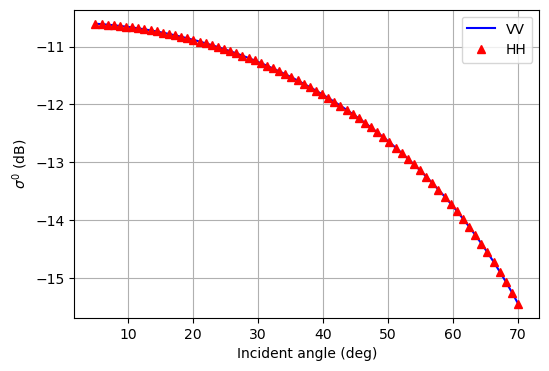

ks:0.0225, ka:0.1275, ke:0.15, ssa:0.15


In [5]:
freq = 10e9
ke = 0.15
a = 0.15
ks = ke * a
ka = ke - ks
epsr_bg = 6
d = 5
##################################################################
# surface = TransparentSurface(epsilon_r=epsr_bg)
surface = SmoothSurface(epsilon_r=epsr_bg)
# layer = RayleighSphere(f=mores.freq, epsr_background=8.0, epsr_particle=3.2-3.2j, radius=0.05*3e8/mores.freq, fs=0.001, thickness=10)
layer = RayleighSphereKsKa(f=freq, epsr_background=epsr_bg, ks=ks, ka=ka, thickness=d)
# subsurface = AIEM(epsilon_r=8.0, kdel=0.3, kcor=1.0)

vrt = VRT(surface, layer)
# run model and plot
theta_is = np.linspace(5., 70., 70)
Num = len(theta_is)
sigma0_VVs = np.zeros(Num)
sigma0_HHs = np.zeros(Num)
sigma0_HVs = np.zeros(Num)
for i in range(Num):
    theta_i = theta_is[i]
    # Mue = vrt.test_Mue_volume_nosurface((theta_i, 180, theta_i, 0))
    Mue = vrt.Mue_volume_nosurface((theta_i, 180, theta_i, 0))
    # Mue = vrt.Mue_surface((theta_i, 180, theta_i, 0))
    # Mue = vrt.Mue_volume((theta_i, 180, theta_i, 0))
    # Mue = vrt.subsurface((theta_i, 180, theta_i, 0))
    # Mue = vrt.Mue_volume((theta_i, 180, theta_i, 0)) + vrt.Mue_surface((theta_i, 180, theta_i, 0))
    sigma_VV, _, sigma_HV, sigma_HH = Mueller2sigma0VH(Mue)
    sigma0_VVs[i] = sigma_VV
    sigma0_HHs[i] = sigma_HH
    sigma0_HVs[i] = sigma_HV

sigma0_VV_dB = 10*np.log10(sigma0_VVs)
sigma0_HH_dB = 10*np.log10(sigma0_HHs)
sigma0_HV_dB = 10*np.log10(sigma0_HVs)
plt.figure(figsize=(6, 4))
plt.plot(theta_is, sigma0_VV_dB, 'b-', label='VV')
plt.plot(theta_is, sigma0_HH_dB, 'r^', label='HH')
# plt.plot(theta_is, sigma0_HV_dB, 'g--', label='HV')
# plt.ylim(-45, 0)
plt.xlabel('Incident angle (deg)')
plt.ylabel('$\sigma^0$ (dB)')
plt.legend()
plt.grid()
plt.show()
layer.print_params()

In [6]:
sigma0_HVs

array([1.30364677e-33, 1.30072464e-33, 1.29730666e-33, 1.29339628e-33,
       1.28899742e-33, 1.28411449e-33, 1.27875235e-33, 1.27291634e-33,
       1.26661223e-33, 1.25984622e-33, 1.25262494e-33, 1.24495543e-33,
       1.23684510e-33, 1.22830175e-33, 1.21933355e-33, 1.20994898e-33,
       1.20015687e-33, 1.18996634e-33, 1.17938682e-33, 1.16842798e-33,
       1.15709975e-33, 1.14541228e-33, 1.13337595e-33, 1.12100129e-33,
       1.10829901e-33, 1.09527998e-33, 1.08195517e-33, 1.06833564e-33,
       1.05443257e-33, 1.04025715e-33, 1.02582063e-33, 1.01113427e-33,
       9.96209320e-34, 9.81057003e-34, 9.65688490e-34, 9.50114885e-34,
       9.34347201e-34, 9.18396342e-34, 9.02273083e-34, 8.85988055e-34,
       8.69551720e-34, 8.52974361e-34, 8.36266063e-34, 8.19436694e-34,
       8.02495893e-34, 7.85453054e-34, 7.68317314e-34, 7.51097537e-34,
       7.33802306e-34, 7.16439908e-34, 6.99018326e-34, 6.81545227e-34,
       6.64027957e-34, 6.46473532e-34, 6.28888628e-34, 6.11279582e-34,
      